**Exercise**

1. Load the iris data set using sklearn datasets

2. Set X to contain the feature matrix

3. Set y to contain the target vector​‌

4. Fit a Kmeans Clustering model with 3 clusters​‌

5. Get resulting groups​‌

6. For each group, find the most ocurring flower type for each group

7. Having the labels for each group, see the confusion matrix and the accuracy score

8. Use the above clustering evaluation metrics (with/without true y) to evaluate the performance of the clustering

9. Do we really see the flower groups here or should there be more/less?

10. Plot using the elbow method. Plot using silhoutte coefficient.

11. Does scaling the data improve the performance of the clustering

In [37]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn import metrics
from sklearn.metrics import davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import mode

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

iris = load_iris()

print("Data shape:", iris.data.shape)
print("Target names:", iris.target_names)
print("Feature names:", iris.feature_names)

Data shape: (150, 4)
Target names: ['setosa' 'versicolor' 'virginica']
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [38]:
X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Feature names:", feature_names)
print("Target names:", target_names)

Feature matrix shape: (150, 4)
Target vector shape: (150,)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']


In [39]:
iris_km = KMeans(n_clusters=3, random_state=0, n_init=10)
groups = iris_km.fit_predict(X)

print("Resulting cluster groups:")
print(groups)

Resulting cluster groups:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


In [40]:
centers_df = pd.DataFrame(
    iris_km.cluster_centers_,
    columns=iris.feature_names
)

centers_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.901613,2.748387,4.393548,1.433871
1,5.006000,3.428000,1.462000,0.246000
2,6.850000,3.073684,5.742105,2.071053


In [41]:
# most occuring flower

labels = np.zeros_like(clusters)

for i in range(3):
    mask = (clusters == i)
    most_occuring = mode(y[mask], keepdims=True)[0][0]
    labels[mask] = most_occuring

    print("Cluster:", i)
    print("Most occurring flower type:", iris.target_names[most_occuring])
    print("Label number:", most_occuring)
    print("Number of samples in cluster:", np.sum(mask))
    print()

Cluster: 0
Most occurring flower type: versicolor
Label number: 1
Number of samples in cluster: 62

Cluster: 1
Most occurring flower type: setosa
Label number: 0
Number of samples in cluster: 50

Cluster: 2
Most occurring flower type: virginica
Label number: 2
Number of samples in cluster: 38



In [42]:
# Accuracy score
acc = accuracy_score(y, labels)
print("Accuracy Score:", acc)

Accuracy Score: 0.8933333333333333


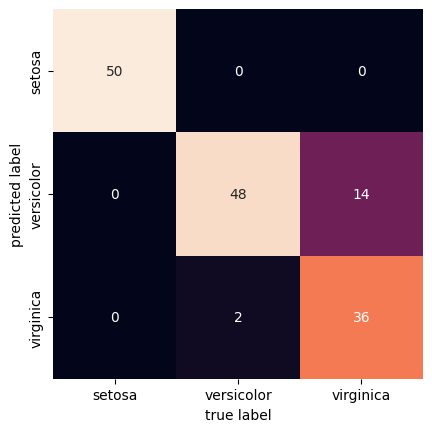

In [43]:
# Confusion matrix
mat = confusion_matrix(y, labels)

sns.heatmap(
    mat.T,
    square=True,
    annot=True,
    fmt='d',
    cbar=False,
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel('true label')
plt.ylabel('predicted label')
plt.show()

In [44]:
# With true labels
ari = metrics.adjusted_rand_score(y, clusters)
print("Adjusted Rand Score:", ari)

Adjusted Rand Score: 0.7302382722834697


In [45]:
# Without true labels

s = metrics.silhouette_score(X, clusters, metric='euclidean')
print("Silhouette Score:", s)

Silhouette Score: 0.5528190123564095


In [27]:
# DB score

db = davies_bouldin_score(X, clusters)
print("Davies Bouldin Score:", db)

Davies Bouldin Score: 0.6619715465007465


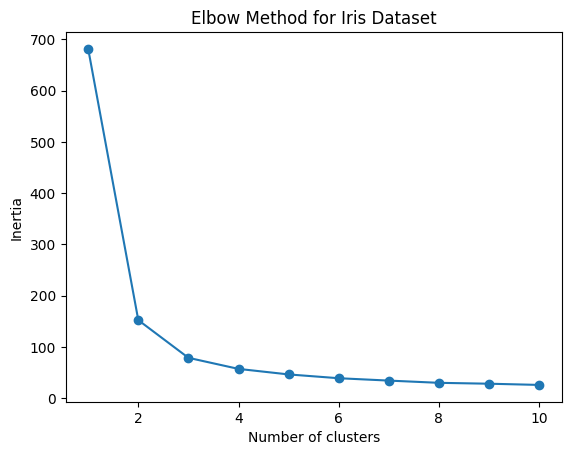

In [28]:
# Elbow method

inertia = []
k_values = range(1, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Iris Dataset')
plt.show()

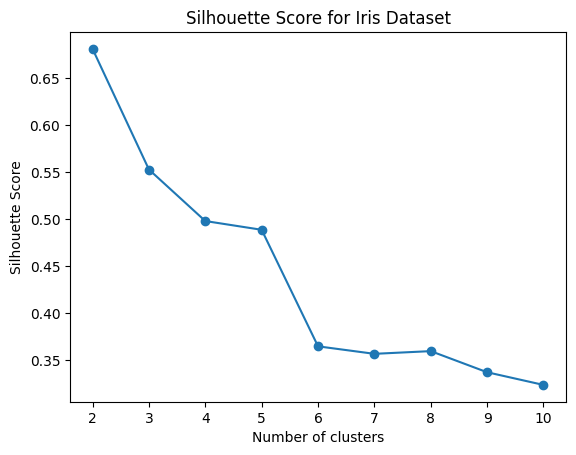

In [25]:
#silhoutte coeffieicnt plot

silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    cluster_labels = km.fit_predict(X)

    score = metrics.silhouette_score(X, cluster_labels)
    silhouette_scores.append(score)

plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Iris Dataset')
plt.show()

In [32]:
#scale the data
scaler = StandardScaler()
iris_scaled = scaler.fit_transform(X)

iris_km_scaled = KMeans(n_clusters=3, random_state=0, n_init=10)
clusters_scaled = iris_km_scaled.fit_predict(iris_scaled)

labels_scaled = np.zeros_like(clusters_scaled)

for i in range(3):
    mask = (clusters_scaled == i)
    most_occuring = mode(y[mask], keepdims=True)[0][0]
    labels_scaled[mask] = most_occuring

    print("Cluster:", i)
    print("Most occurring flower type:", iris.target_names[most_occuring])
    print("Label number:", most_occuring)
    print("Number of samples in cluster:", np.sum(mask))
    print()

Cluster: 0
Most occurring flower type: versicolor
Label number: 1
Number of samples in cluster: 53

Cluster: 1
Most occurring flower type: setosa
Label number: 0
Number of samples in cluster: 50

Cluster: 2
Most occurring flower type: virginica
Label number: 2
Number of samples in cluster: 47



In [34]:
# Accuracy after scaling

acc_scaled = accuracy_score(y, labels_scaled)
print("Accuracy Score after scaling:", acc_scaled)

Accuracy Score after scaling: 0.8333333333333334


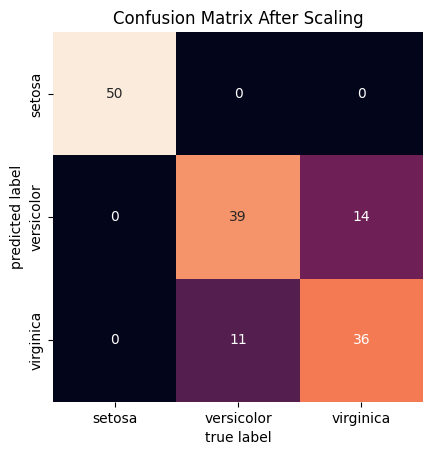

In [35]:
#confusion matrix after scaling

mat_scaled = confusion_matrix(y, labels_scaled)

sns.heatmap(
    mat_scaled.T,
    square=True,
    annot=True,
    fmt='d',
    cbar=False,
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel('true label')
plt.ylabel('predicted label')
plt.title('Confusion Matrix After Scaling')
plt.show()

In [36]:
# Evaluation metrics after scaling

ari_scaled = metrics.adjusted_rand_score(y, clusters_scaled)
s_scaled = metrics.silhouette_score(iris_scaled, clusters_scaled, metric='euclidean')
db_scaled = davies_bouldin_score(iris_scaled, clusters_scaled)

print("Adjusted Rand Score after scaling:", ari_scaled)
print("Silhouette Score after scaling:", s_scaled)
print("Davies Bouldin Score after scaling:", db_scaled)

Adjusted Rand Score after scaling: 0.6201351808870379
Silhouette Score after scaling: 0.45994823920518635
Davies Bouldin Score after scaling: 0.8335949464754338
